# Week 2 Data QC and Experimental Feature Encoding

This notebook documents the quality control workflow for the CMsiRNAdb dataset.

## QC Rules Table for the Report

| QC Area | Rule | Action | Reason |
|---|---|---|---|
| Inhibition | Keep values between -100 and 100 inclusive | Remove rows with `Inhibition < -100` or `Inhibition > 100` | Mild negative inhibition is treated as a real biological outcome, but extreme values are considered implausible |
| Strand length | Each strand must be 25 bases or shorter | Remove rows where either strand length is greater than 25 | Longer strands may represent molecules outside the standard siRNA scope |
| Sequence validity | Sequence strings must use valid nucleotide characters | Flag invalid sequence rows for review | Invalid characters can break sequence encoding |
| Sequence length consistency | Stored strand length should match the actual sequence length | Flag mismatches for review | Length mismatches indicate inconsistent records |
| Experimental setting | Focus on in vitro concentration units | Remove rows using `mg/kg` | `mg/kg` reflects in vivo dosing and is outside the current project scope |
| Concentration units | Standardize `pM`, `nM`, and `uM` into a common unit | Convert to nM and flag unsupported units such as `mM` | Mixed units cannot be modeled directly without normalization |
| Cell type | Cell type must be known and interpretable | Remove rows with missing, `Unknown cell line`, or suspected reporter-assay labels such as `RGA` | Unclear biological context reduces comparability |
| Experimental metadata | Concentration and time must be present and usable for the experimental-feature subset | Remove rows with missing, unknown, or unusable concentration/time entries | These variables are required for experimental feature encoding |
| Duplicate records | Inspect duplicate IDs and exact duplicate rows | Flag duplicates; do not drop automatically without context | Some duplicated IDs may reflect repeated measurements |
| Chemistry annotations | Modification columns should be consistent with positions and strand length | Flag invalid or unparsable annotations | Chemistry encoding depends on valid positional annotations |

### Notes

- Mild negative inhibition values are kept as-is.
- `mg/kg` rows are excluded from the modeling subset because they represent in vivo dosing.
- `mM` rows are still inspected separately and then removed before the final no-`mM` subset is saved.
- The current dataset does not contain a transfection-method column, so experimental-condition QC is enforced on `Cell_Type`, `Concentration`, and `Time_of_administration`.

In [4]:
# Import the main libraries used for data loading, analysis, plotting, and parsing.
import os
from pathlib import Path
import re

# Import numerical and tabular analysis libraries.
import numpy as np
import pandas as pd

# Import plotting libraries for the presentation-ready charts.
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent plotting style for easier visual comparison across QC steps.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)


## 1. Dataset Overview

In [5]:
# Resolve the project root and load the raw-data path from the environment.
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
raw_data_path_env = os.environ.get("CMSIRNA_RAW_DATA_PATH")
processed_dir_env = os.environ.get("CMSIRNA_PROCESSED_DIR")

# Fail early with a clear message if the required environment variables are not set.
if not raw_data_path_env:
    raise ValueError("Set CMSIRNA_RAW_DATA_PATH in your local .envrc before running this notebook.")
if not processed_dir_env:
    raise ValueError("Set CMSIRNA_PROCESSED_DIR in your local .envrc before running this notebook.")

# Convert the environment variables into pathlib paths.
data_path = Path(raw_data_path_env).expanduser()
processed_dir = Path(processed_dir_env).expanduser()

# Load the raw dataset as a pandas dataframe.
df_raw = pd.read_csv(data_path, sep="\t", low_memory=False)

# Make a working copy so the raw dataframe stays unchanged for before/after comparisons.
df = df_raw.copy()

# Print the basic dataset size and preview the first rows.
print("Raw shape:", df.shape)
display(df.head())


Raw shape: (43153, 26)


,ID,patent_ID,Authorization_status,Accession_number,Target_Gene,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Modification_locations_Antisense_strand,position_Antisense_strand,Sense_seqence,length_sense_strand,Modifications_sense_strand,Modification_Types_Sense_strand,Modification_locations_Sense_strand,position_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,Modifications_AntiSense_strand_3_5
0,001-01-01-00001-100n-48h-88.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D1,UUAGAAAGCUGAUGGACCAUAACUG,25.0,UUAGAAAGCUGAUGGACCAUAACUG,1*U || 2*U || 3*A || 4*G || 5*A || 6*A || 7*A ...,NaN,NaN,CAGUUAUGGUCCAUCAGCUUUCUAA,25.0,mCmAmGmUmUmAmUGGUCCAUCAGC(mU)mUmUmCmUmAmA,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",88.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,GUCAAUACCAGGUAGUCGAAAGAUU
1,001-01-01-00002-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D2,UACAAUAGCAGACACCAUCUGAGGA,25.0,UACAAUAGCAGACACCAUCUGAGGA,1*U || 2*A || 3*C || 4*A || 5*A || 6*U || 7*A ...,NaN,NaN,UCCUCAGAUGGUGUCUGCUAUUGUA,25.0,mUmCmCmUmCmAmGAUGGUGUCUGC(mU)mAmUmUmGmUmA,1*2'-O-Methyluridine || 2*2'-O-Methylcytidine ...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",90.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,AGGAGUCUACCACAGACGAUAACAU
2,001-01-01-00003-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D3,UGAACAAGACGUUGACUUGGAUCUG,25.0,UGAACAAGACGUUGACUUGGAUCUG,1*U || 2*G || 3*A || 4*A || 5*C || 6*A || 7*A ...,NaN,NaN,CAGAUCCAAGUCAACGUCUUGUUCA,25.0,mCmAmGmAmUmCmCAAGUCAACGUC(mU)mUmGmUmUmCmA,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",90.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,GUCUAGGUUCAGUUGCAGAACAAGU
3,001-01-01-00004-100n-48h-89.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D4,UUUAGUUGCAGCAUCUGAAAGAUUC,25.0,UUUAGUUGCAGCAUCUGAAAGAUUC,1*U || 2*U || 3*U || 4*A || 5*G || 6*U || 7*U ...,NaN,NaN,GAAUCUUUCAGAUGCUGCAACUAAA,25.0,mGmAmAmUmCmUmUUCAGAUGCUGC(mA)mAmCmUmAmAmA,1*2'-O-Methylguanosine || 2*2'-O-Methyladenosi...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",89.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,CUUAGAAAGUCUACGACGUUGAUUU
4,001-01-01-00005-100n-48h-87.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D5,UUUCGAAUCAAUCCAACAGUAGCCU,25.0,UUUCGAAUCAAUCCAACAGUAGCCU,1*U || 2*U || 3*U || 4*C || 5*G || 6*A || 7*A ...,NaN,NaN,AGGCUACUGUUGGAUUGAUUCGAAA,25.0,mAmGmGmCmUmAmCUGUUGGAUUGA(mU)mUmCmGmAmAmA,1*2'-O-Methyladenosine || 2*2'-O-Methylguanosi...,Sugar,"1,2,3,4,5,6,7,19,20,21,22,23,24,25",87.0,NaN,Hela,100nM,48h,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,UCCGAUGACAACCUAACUAAGCUUU


## 2. Missing Values Profile

,missing_count,missing_percent
SD,25531,59.16
Time_of_administration,8765,20.31
Accession_number,4032,9.34
Gene_ID,4032,9.34
Modification_locations_Sense_strand,3813,8.84
Modification_locations_Antisense_strand,3808,8.82
The_name_of_double_helix,3683,8.53
position_Sense_strand,3565,8.26
position_Antisense_strand,3558,8.25
length_sense_strand,3462,8.02


<Figure size 1000x600 with 0 Axes>

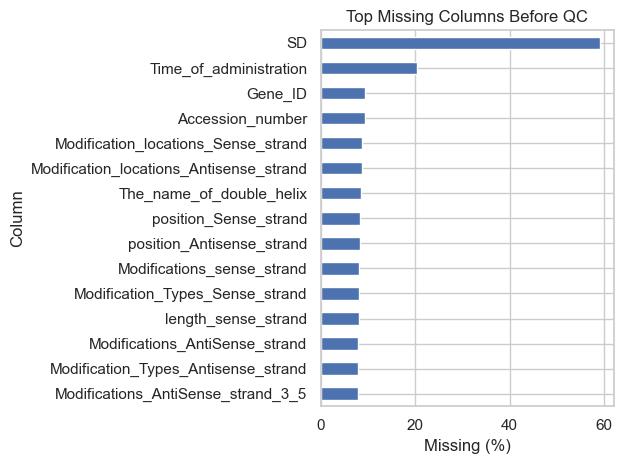

In [7]:
# Count missing values in each column and compute their percentages.
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_count / len(df) * 100).round(2)

# Build a compact missingness summary table.
missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent,
})

# Display the full missingness table for reporting.
display(missing_df)

# Plot the columns with the most missing values for a quick presentation graphic.
plt.figure(figsize=(10, 6))
missing_df.head(15).sort_values("missing_percent").plot(kind="barh", y="missing_percent", legend=False)
plt.title("Top Missing Columns Before QC")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()


## 3. Duplicate Checks

In [8]:
# Measure exact row duplication and duplicated IDs separately.
duplicate_summary = pd.DataFrame({
    "metric": [
        "Exact duplicate rows",
        "Duplicated IDs",
        "Duplicated antisense sequences",
        "Duplicated sense sequences",
    ],
    "count": [
        int(df.duplicated().sum()),
        int(df["ID"].duplicated().sum()),
        int(df["Antisense_seqence"].duplicated().sum()),
        int(df["Sense_seqence"].duplicated().sum()),
    ],
})

# Add the duplicate percentage so it is easier to report how repetitive the dataset is.
duplicate_summary["percent_of_dataset"] = (duplicate_summary["count"] / len(df) * 100).round(2)

# Display the duplicate summary and inspect a few duplicated IDs.
display(duplicate_summary)
display(df[df["ID"].duplicated(keep=False)].sort_values("ID").head(20))


,metric,count,percent_of_dataset
0,Exact duplicate rows,0,0.00
1,Duplicated IDs,75,0.17
2,Duplicated antisense sequences,31931,73.99
3,Duplicated sense sequences,32668,75.70


,ID,patent_ID,Authorization_status,Accession_number,Target_Gene,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Modification_locations_Antisense_strand,position_Antisense_strand,Sense_seqence,length_sense_strand,Modifications_sense_strand,Modification_Types_Sense_strand,Modification_locations_Sense_strand,position_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,Modifications_AntiSense_strand_3_5
7225,004-03-06-02617-2m-XXX-80.00,CN108368506A,Substantive Examination,NaN,LPA,NaN,AD01184,TGUAUAACAAUAAGGGGCUTT,21.0,dTGfuAfuAfaCfaAfuaaGfgGfgCfudTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,"Phosphate, Sugar","1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...",UAUAGCCCCUUAUUGUUAUACAT,23.0,(Chol-TEG)uAuAfgCfcCfcUfUfAfuUfgUfuAfuAfcAf(in...,Chol-TEG || 1*2'-O-Methyluridine || 2*A || 3*2...,Sugar,"1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...",80.0,NaN,Transgenic mice,2mg/kg,NaN,用于抑制LPA的基因表达的组合物和方法,dTdTsuCfgGfgGfaauAfaCfaAfuAfuGfdT
7582,004-03-06-02617-2m-XXX-80.00,CN108368506A,Substantive Examination,NaN,LPA,NaN,AD01184,TGUAUAACAAUAAGGGGCUTT,21.0,dTGfuAfuAfaCfaAfuaaGfgGfgCfudTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,"Phosphate, Sugar","1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...",UAUAGCCCCUUAUUGUUAUACAT,23.0,(Chol-TEG)uAuAfgCfcCfcUfUfAfuUfgUfuAfuAfcAf(in...,Chol-TEG || 1*2'-O-Methyluridine || 2*A || 3*2...,Sugar,"1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...",80.0,5,Transgenic mice,2mg/kg,9 days,用于抑制LPA的基因表达的组合物和方法,dTdTsuCfgGfgGfaauAfaCfaAfuAfuGfdT
7227,004-03-06-02619-2m-XXX-83.00,CN108368506A,Substantive Examination,NaN,LPA,NaN,AD01190,TGCGUCUGAGCAUUGUGUCTT,21.0,dTGfcGfuCfuGfaGfcauUfgUfgUfcdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,"Phosphate, Sugar","1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...",UAUGACACAAUGCUCAGACGCAT,23.0,(Chol-TEG)uAuGfaCfaCfaAfUfGfcUfcAfgAfcGfcAf(in...,Chol-TEG || 1*2'-O-Methyluridine || 2*A || 3*2...,Sugar,"1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...",83.0,NaN,Transgenic mice,2mg/kg,NaN,用于抑制LPA的基因表达的组合物和方法,dTdTscUfgUfgUfuacGfaGfuCfuGfcGfdT
7584,004-03-06-02619-2m-XXX-83.00,CN108368506A,Substantive Examination,NaN,LPA,NaN,AD01190,TGCGUCUGAGCAUUGUGUCTT,21.0,dTGfcGfuCfuGfaGfcauUfgUfgUfcdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,"Phosphate, Sugar","1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...",UAUGACACAAUGCUCAGACGCAT,23.0,(Chol-TEG)uAuGfaCfaCfaAfUfGfcUfcAfgAfcGfcAf(in...,Chol-TEG || 1*2'-O-Methyluridine || 2*A || 3*2...,Sugar,"1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...",83.0,7,Transgenic mice,2mg/kg,9 days,用于抑制LPA的基因表达的组合物和方法,dTdTscUfgUfgUfuacGfaGfuCfuGfcGfdT
7556,004-03-06-02619-8m-XXX-100.00,CN108368506A,Substantive Examination,NaN,LPA,NaN,AD01190,TGCGUCUGAGCAUUGUGUCTT,21.0,dTGfcGfuCfuGfaGfcauUfgUfgUfcdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,"Phosphate, Sugar","1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...",UAUGACACAAUGCUCAGACGCAT,23.0,(Chol-TEG)uAuGfaCfaCfaAfUfGfcUfcAfgAfcGfcAf(in...,Chol-TEG || 1*2'-O-Methyluridine || 2*A || 3*2...,Sugar,"1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...",100.0,0,Transgenic mice,8mg/kg,29 days,用于抑制LPA的基因表达的组合物和方法,dTdTscUfgUfgUfuacGfaGfuCfuGfcGfdT
7549,004-03-06-02619-8m-XXX-100.00,CN108368506A,Substantive Examination,NaN,LPA,NaN,AD01190,TGCGUCUGAGCAUUGUGUCTT,21.0,dTGfcGfuCfuGfaGfcauUfgUfgUfcdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,"Phosphate, Sugar","1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...",UAUGACACAAUGCUCAGACGCAT,23.0,(Chol-TEG)uAuGfaCfaCfaAfUfGfcUfcAfgAfcGfcAf(in...,Chol-TEG || 1*2'-O-Methyluridine || 2*A || 3*2...,Sugar,"1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...",100.0,0,Transgenic mice,8mg/kg,22 days,用于抑制LPA的基因表达的组合物和方法,dTdTscUfgUfgUfuacGfaGfuCfuGfcGfdT
7542,004-03-06-02619-8m-XXX-100.00,CN108368506A,Substantive Examination,NaN,LPA,NaN,AD01190,TGCGUCUGAGCAUUGUGUCTT,21.0,dTGfcGfuCfuGfaGfcauUfgUfgUfcdTsdT,1*2'-Deoxy 

## 4. Inhibition QC

count    4.315300e+04
mean    -1.233932e+02
std      3.419604e+04
min     -7.103597e+06
25%      1.420000e+01
50%      4.400000e+01
75%      7.070000e+01
max      1.000000e+02
Name: Inhibition, dtype: float64

Rows with inhibition outside [-100, 100]: 102


,ID,Target_Gene,Cell_Type,Concentration,Time_of_administration,Inhibition
3412,003-02-02-00972-0.1n-24h--105.27,INHBE,Hep3B,0.1nM,24h,-105.27
7567,004-03-06-02627-8m-XXX--109.00,LPA,Transgenic mice,8mg/kg,36 days,-109.00
7774,005-03-06-02922-2m-XXX--103.00,LPA,Transgenic mice,2mg/kg,28 days,-103.00
7858,005-03-06-02953-1m-XXX--300.00,LPA,Transgenic mice,1mg/kg,28 days,-300.00
8585,008-03-05-03206-0.1n-24h--407.00,LPA,Huh7,0.1nM,24h,-407.00
8595,008-03-05-03216-0.1n-24h--184.00,LPA,Huh7,0.1nM,24h,-184.00
8611,008-03-05-03178-10n-24h--500.00,LPA,Huh7,10nM,24h,-500.00
8619,008-03-05-03186-10n-24h--1869.00,LPA,Huh7,10nM,24h,-1869.00
8625,008-03-05-03192-10n-24h--163.00,LPA,Huh7,10nM,24h,-163.00
8628,008-03-05-03195-10n-24h--162.00,LPA,Huh7,10nM,24h,-162.00


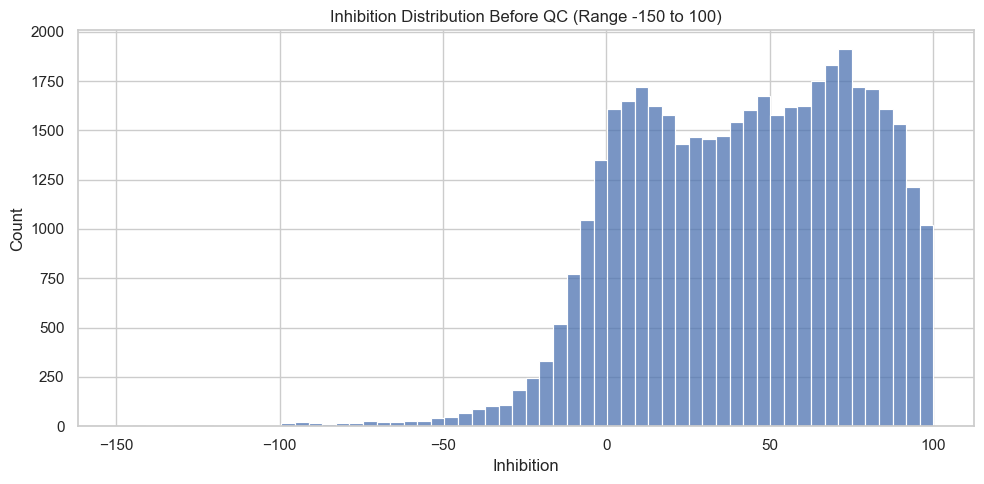

In [9]:
# Summarize the inhibition distribution before filtering.
display(df["Inhibition"].describe())

# Flag inhibition values outside the agreed project range.
df["flag_inhibition_out_of_range"] = (df["Inhibition"] < -100) | (df["Inhibition"] > 100)

# Display the number of out-of-range rows and a few examples.
print("Rows with inhibition outside [-100, 100]:", int(df["flag_inhibition_out_of_range"].sum()))
display(df.loc[df["flag_inhibition_out_of_range"], ["ID", "Target_Gene", "Cell_Type", "Concentration", "Time_of_administration", "Inhibition"]].head(20))

# Plot the raw inhibition distribution to show the extreme tail before QC.
plot_df = df[df["Inhibition"].between(-150, 100)]

plt.figure(figsize=(10, 5))
sns.histplot(plot_df["Inhibition"], bins=60)
plt.title("Inhibition Distribution Before QC (Range -150 to 100)")
plt.xlabel("Inhibition")
plt.tight_layout()
plt.show()


## 5. Sequence and Strand QC

In [10]:
# Define a helper function to count invalid sequence characters and length mismatches.
def sequence_qc_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for seq_col, len_col in [
        ("Antisense_seqence", "length_anti_sense_strand"),
        ("Sense_seqence", "length_sense_strand"),
    ]:
        seq_series = frame[seq_col].astype(str)
        seq_length = seq_series.str.len()
        invalid_chars = ~seq_series.str.fullmatch(r"[ACGUTacgut]+", na=False)
        length_mismatch = frame[len_col].notna() & (seq_length != frame[len_col].astype(float))
        over_25 = frame[len_col].fillna(seq_length).astype(float) > 25
        rows.append({
            "sequence_column": seq_col,
            "missing_sequence": int(frame[seq_col].isna().sum()),
            "invalid_characters": int(invalid_chars.sum()),
            "length_mismatch": int(length_mismatch.sum()),
            "over_25_bases": int(over_25.sum()),
        })
    return pd.DataFrame(rows)

# Build and display the sequence QC summary table.
sequence_summary = sequence_qc_table(df)
display(sequence_summary)

# Create row-level flags for sequence-based QC failures.
antisense_len = df["Antisense_seqence"].astype(str).str.len()
sense_len = df["Sense_seqence"].astype(str).str.len()
df["flag_invalid_antisense_chars"] = ~df["Antisense_seqence"].astype(str).str.fullmatch(r"[ACGUTacgut]+", na=False)
df["flag_invalid_sense_chars"] = ~df["Sense_seqence"].astype(str).str.fullmatch(r"[ACGUTacgut]+", na=False)
df["flag_antisense_length_mismatch"] = df["length_anti_sense_strand"].notna() & (antisense_len != df["length_anti_sense_strand"].astype(float))
df["flag_sense_length_mismatch"] = df["length_sense_strand"].notna() & (sense_len != df["length_sense_strand"].astype(float))
df["flag_over_25_bases"] = (df["length_anti_sense_strand"].fillna(antisense_len).astype(float) > 25) | (df["length_sense_strand"].fillna(sense_len).astype(float) > 25)

# Inspect a few rows that would be removed because one strand exceeds 25 bases.
display(df.loc[df["flag_over_25_bases"], ["ID", "Antisense_seqence", "length_anti_sense_strand", "Sense_seqence", "length_sense_strand"]].head(20))


,sequence_column,missing_sequence,invalid_characters,length_mismatch,over_25_bases
0,Antisense_seqence,1,276,3272,3022
1,Sense_seqence,0,1187,3639,2383


,ID,Antisense_seqence,length_anti_sense_strand,Sense_seqence,length_sense_strand
5232,004-03-02-01383-XX-XXX-23.00,TGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5233,004-03-02-01384-XX-XXX-23.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5234,004-03-02-01385-XX-XXX--1.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5235,004-03-02-01386-XX-XXX-3.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5236,004-03-02-01387-XX-XXX-22.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5237,004-03-02-01388-XX-XXX--6.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5238,004-03-02-01389-XX-XXX--6.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5239,004-03-02-01390-XX-XXX-14.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5240,004-03-02-01391-XX-XXX--8.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0
5241,004-03-02-01392-XX-XXX-1.00,UGAGAAUGAGCCUCGAUAACUCUUAU,26.0,UAUAUAGUUAUCGAGGCUCAUUCUCA,26.0


## 6. Experimental Metadata QC

In [7]:
# Review the main experimental metadata columns before cleaning.
# Note: this dataset does not include a transfection-method column, so the experimental-condition QC focuses on cell type, concentration, and time.
for column in ["Cell_Type", "Concentration_unit", "Time_of_administration", "Authorization_status", "Target_Gene"]:
    print(f"\n--- {column} ({df[column].nunique(dropna=True)} unique) ---")
    display(df[column].value_counts(dropna=False).head(25))

# Plot the most frequent cell types to show category imbalance before standardization.
plt.figure(figsize=(10, 6))
df["Cell_Type"].value_counts().head(15).sort_values().plot(kind="barh")
plt.title("Top Cell Types Before QC")
plt.xlabel("Count")
plt.tight_layout()
plt.show()



--- Cell_Type (39 unique) ---


Cell_Type
Hep3B                                                        12902
Primary Cynomolgus Monkey Hepatocytes                         4722
COS7                                                          3888
Primary human hepatocytes                                     3497
Huh7                                                          3424
Transgenic mice                                               3245
HepG2                                                         2910
Hela                                                          2048
Be(2)C cell line                                              1982
HEK293A                                                       1048
Primary mouse hepatocytes                                      501
Macaca fascicularis                                            483
Neuro2A cell line                                              454
Human iPSC-derived cortical neurons                            437
T98G cell                                           

KeyError: 'Concentration_unit'

In [3]:
# Define a parser that splits a concentration string into numeric value and unit.
def parse_concentration(value):
    if pd.isna(value):
        return np.nan, np.nan
    text = str(value).strip().replace(" ", "")
    match = re.fullmatch(r"([0-9]*\.?[0-9]+)([A-Za-z/]+)", text)
    if not match:
        return np.nan, text
    numeric_value = float(match.group(1))
    unit = match.group(2)
    return numeric_value, unit

# Apply the parser to create cleaned concentration value and unit columns.
df[["Concentration_value", "Concentration_unit"]] = df["Concentration"].apply(parse_concentration).apply(pd.Series)

# Normalize common unit spellings into a smaller set.
unit_map = {
    "nm": "nM",
    "nM": "nM",
    "um": "uM",
    "uM": "uM",
    "pm": "pM",
    "pM": "pM",
    "mm": "mM",
    "mM": "mM",
    "mg/kg": "mg/kg",
}
df["Concentration_unit_clean"] = df["Concentration_unit"].map(unit_map).fillna(df["Concentration_unit"])

# Convert in vitro units to a common nM scale for downstream modeling.
def concentration_to_nm(row):
    value = row["Concentration_value"]
    unit = row["Concentration_unit_clean"]
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    if unit == "pM":
        return value / 1000
    if unit == "nM":
        return value
    if unit == "uM":
        return value * 1000
    return np.nan

# Create the normalized concentration column and QC flags for unsupported or unusable concentration entries.
df["Concentration_nM"] = df.apply(concentration_to_nm, axis=1)
df["flag_in_vivo_mgkg"] = df["Concentration_unit_clean"].eq("mg/kg")
df["flag_mM_unit"] = df["Concentration_unit_clean"].eq("mM")
df["flag_unparseable_concentration"] = df["Concentration"].notna() & df["Concentration_value"].isna()
df["flag_missing_concentration"] = df["Concentration"].isna()
known_concentration_units = {"pM", "nM", "uM", "mM", "mg/kg"}
df["flag_unknown_concentration_unit"] = df["Concentration"].notna() & ~df["Concentration_unit_clean"].isin(known_concentration_units)
df["flag_unusable_concentration_for_encoding"] = (
    df["flag_missing_concentration"]
    | df["flag_unparseable_concentration"]
    | df["flag_in_vivo_mgkg"]
    | df["flag_unknown_concentration_unit"]
)

# Display the parsed concentration overview and the rows with unusable concentration metadata.
display(df[["Concentration", "Concentration_value", "Concentration_unit_clean", "Concentration_nM"]].head(20))
display(df["Concentration_unit_clean"].value_counts(dropna=False))
display(df.loc[df["flag_unusable_concentration_for_encoding"], ["ID", "Concentration", "Concentration_value", "Concentration_unit_clean", "Concentration_nM"]].head(25))


,Concentration,Concentration_value,Concentration_unit_clean,Concentration_nM
0,100nM,100.0,nM,100.0
1,100nM,100.0,nM,100.0
2,100nM,100.0,nM,100.0
3,100nM,100.0,nM,100.0
4,100nM,100.0,nM,100.0
5,100nM,100.0,nM,100.0
6,100nM,100.0,nM,100.0
7,10nM,10.0,nM,10.0
8,10nM,10.0,nM,10.0
9,10nM,10.0,nM,10.0


Concentration_unit_clean
nM       36451
mg/kg     4180
NaN       1797
mM         565
uM          45
1μM         35
0.1μM       35
10μM        31
pM           5
mg           5
lnM          4
Name: count, dtype: int64

,ID,Concentration,Concentration_value,Concentration_unit_clean,Concentration_nM
7225,004-03-06-02617-2m-XXX-80.00,2mg/kg,2.0,mg/kg,NaN
7226,004-03-06-02618-2m-XXX-82.00,2mg/kg,2.0,mg/kg,NaN
7227,004-03-06-02619-2m-XXX-83.00,2mg/kg,2.0,mg/kg,NaN
7228,004-03-06-02620-2m-XXX-78.00,2mg/kg,2.0,mg/kg,NaN
7229,004-03-06-02621-2m-XXX-98.00,2mg/kg,2.0,mg/kg,NaN
7230,004-03-06-02622-2m-XXX-93.50,2mg/kg,2.0,mg/kg,NaN
7231,004-03-06-02623-2m-XXX-94.90,2mg/kg,2.0,mg/kg,NaN
7232,004-03-06-02624-2m-XXX-93.00,2mg/kg,2.0,mg/kg,NaN
7233,004-03-06-02625-2m-XXX-90.60,2mg/kg,2.0,mg/kg,NaN
7234,004-03-06-02626-2m-XXX-97.10,2mg/kg,2.0,mg/kg,NaN


In [13]:
# Standardize time formatting into a cleaner text field and numeric hours when possible.
def parse_time_to_hours(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    text = text.replace(" ", "")
    if re.fullmatch(r"[0-9]+h", text):
        return float(text[:-1])
    if re.fullmatch(r"[0-9]+days?", text):
        day_value = float(re.findall(r"[0-9]+", text)[0])
        return day_value * 24
    return np.nan

# Apply the time parser and flag entries that are missing or ambiguous for experimental encoding.
df["Time_hours"] = df["Time_of_administration"].apply(parse_time_to_hours)
df["flag_unparseable_time"] = df["Time_of_administration"].notna() & df["Time_hours"].isna()
df["flag_missing_time"] = df["Time_of_administration"].isna()
df["flag_unusable_time_for_encoding"] = df["flag_missing_time"] | df["flag_unparseable_time"]

# Standardize cell type labels and create QC flags for unclear or out-of-scope entries.
cell_type_clean = df["Cell_Type"].astype(str).str.strip()
cell_type_clean = cell_type_clean.replace({
    "Hela": "HeLa",
    "Chinese Hamster Ovary cells(CHO)": "CHO",
})
df["Cell_Type_clean"] = cell_type_clean
df["flag_missing_or_unknown_cell_type"] = df["Cell_Type"].isna() | df["Cell_Type_clean"].str.contains(r"unknown", case=False, na=False)
df["flag_reporter_assay_cell_type"] = df["Cell_Type_clean"].str.contains(r"\brga\b|reporter", case=False, na=False)

# Display suspicious experimental-condition rows to make the filtering decision transparent before the first cleaning step.
display(df.loc[df["flag_missing_or_unknown_cell_type"] | df["flag_reporter_assay_cell_type"], ["ID", "Cell_Type", "Cell_Type_clean", "Target_Gene"]].head(25))
display(df.loc[df["flag_unusable_time_for_encoding"], ["ID", "Time_of_administration", "Time_hours", "Target_Gene"]].head(25))


,ID,Cell_Type,Cell_Type_clean,Target_Gene
40776,080-13-37-14460-30n-XXX-85.00,Unknown cell line,Unknown cell line,PCSK9
40777,080-13-37-14461-30n-XXX-68.00,Unknown cell line,Unknown cell line,PCSK9
40778,080-13-37-14462-30n-XXX-87.00,Unknown cell line,Unknown cell line,PCSK9
40779,080-13-37-14463-30n-XXX-87.00,Unknown cell line,Unknown cell line,PCSK9
40780,080-13-37-14464-30n-XXX-71.00,Unknown cell line,Unknown cell line,PCSK9
40781,080-13-37-14465-30n-XXX-90.00,Unknown cell line,Unknown cell line,PCSK9
40782,080-13-37-14466-30n-XXX-89.00,Unknown cell line,Unknown cell line,PCSK9
40783,080-13-37-14467-30n-XXX-88.00,Unknown cell line,Unknown cell line,PCSK9
40784,080-13-37-14468-30n-XXX-87.00,Unknown cell line,Unknown cell line,PCSK9
40785,080-13-37-14469-30n-XXX-93.00,Unknown cell line,Unknown cell line,PCSK9


,ID,Time_of_administration,Time_hours,Target_Gene
4975,004-03-02-01275-1n-XXX--1.20,NaN,NaN,LPA
4976,004-03-02-01276-1n-XXX-22.40,NaN,NaN,LPA
4977,004-03-02-01277-1n-XXX-29.20,NaN,NaN,LPA
4978,004-03-02-01278-1n-XXX-55.90,NaN,NaN,LPA
4979,004-03-02-01279-1n-XXX-75.80,NaN,NaN,LPA
4980,004-03-02-01280-1n-XXX-83.40,NaN,NaN,LPA
4981,004-03-02-01281-1n-XXX-29.80,NaN,NaN,LPA
4982,004-03-02-01282-1n-XXX-72.80,NaN,NaN,LPA
4983,004-03-02-01283-1n-XXX-71.00,NaN,NaN,LPA
4984,004-03-02-01284-1n-XXX-17.50,NaN,NaN,LPA


## 7. Experimental Value Positivity Checks

,variable,nonpositive_count
0,Concentration_value,0
1,Time_hours,0


,ID,Concentration,Concentration_value,Concentration_unit_clean,Target_Gene


,ID,Time_of_administration,Time_hours,Target_Gene


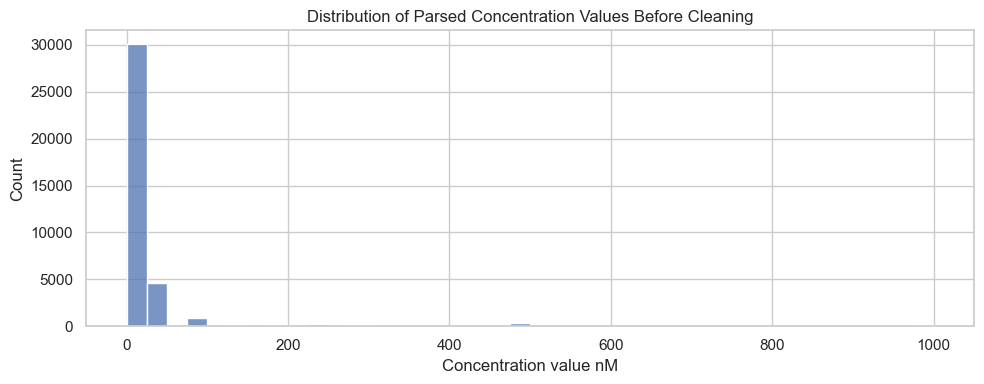

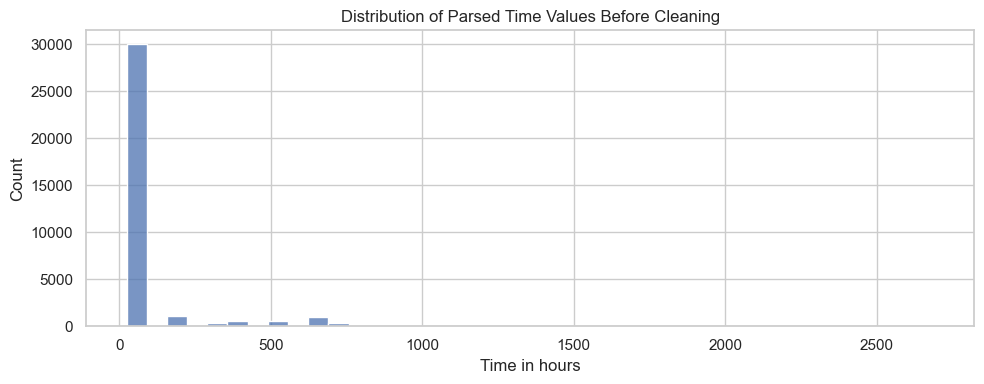

In [14]:
# Check that parsed concentration values are strictly positive whenever they are present.
nonpositive_concentration_count = int((df["Concentration_value"].notna() & (df["Concentration_value"] <= 0)).sum())

# Check that parsed time values are strictly positive whenever they are present.
nonpositive_time_count = int((df["Time_hours"].notna() & (df["Time_hours"] <= 0)).sum())

# Summarize the positivity checks in a compact table for the report.
positivity_summary = pd.DataFrame({
    "variable": ["Concentration_value", "Time_hours"],
    "nonpositive_count": [nonpositive_concentration_count, nonpositive_time_count],
})
display(positivity_summary)

# Display any non-positive concentration rows if they exist.
display(df.loc[df["Concentration_value"].notna() & (df["Concentration_value"] <= 0), ["ID", "Concentration", "Concentration_value", "Concentration_unit_clean", "Target_Gene"]].head(25))

# Display any non-positive time rows if they exist.
display(df.loc[df["Time_hours"].notna() & (df["Time_hours"] <= 0), ["ID", "Time_of_administration", "Time_hours", "Target_Gene"]].head(25))

# Plot the distribution of parsed concentration values before cleaning.
plt.figure(figsize=(10, 4))
sns.histplot(df.loc[df["Concentration_nM"].notna(), "Concentration_nM"], bins=40)
plt.title("Distribution of Parsed Concentration Values Before Cleaning")
plt.xlabel("Concentration value nM")
plt.tight_layout()
plt.show()

# Plot the distribution of parsed time values before cleaning.
plt.figure(figsize=(10, 4))
sns.histplot(df.loc[df["Time_hours"].notna(), "Time_hours"], bins=40)
plt.title("Distribution of Parsed Time Values Before Cleaning")
plt.xlabel("Time in hours")
plt.tight_layout()
plt.show()


## 7. Chemistry Annotation QC

In [15]:
# Define a helper that checks whether modification positions can be parsed and fit within strand length.
def positions_out_of_range(position_text, strand_length):
    if pd.isna(position_text) or pd.isna(strand_length):
        return False
    try:
        positions = [int(item.strip()) for item in str(position_text).split(",") if item.strip()]
    except ValueError:
        return True
    return any(position < 1 or position > int(strand_length) for position in positions)

# Create flags for invalid modification position annotations.
df["flag_antisense_positions_invalid"] = df.apply(
    lambda row: positions_out_of_range(row["position_Antisense_strand"], row["length_anti_sense_strand"]),
    axis=1,
)
df["flag_sense_positions_invalid"] = df.apply(
    lambda row: positions_out_of_range(row["position_Sense_strand"], row["length_sense_strand"]),
    axis=1,
)

# Summarize the chemistry QC flags.
chemistry_summary = pd.DataFrame({
    "metric": [
        "Missing antisense modification types",
        "Missing sense modification types",
        "Invalid antisense position annotations",
        "Invalid sense position annotations",
    ],
    "count": [
        int(df["Modification_Types_Antisense_strand"].isna().sum()),
        int(df["Modification_Types_Sense_strand"].isna().sum()),
        int(df["flag_antisense_positions_invalid"].sum()),
        int(df["flag_sense_positions_invalid"].sum()),
    ],
})
display(chemistry_summary)


,metric,count
0,Missing antisense modification types,3449
1,Missing sense modification types,3462
2,Invalid antisense position annotations,24
3,Invalid sense position annotations,23


## 8. Apply Modeling QC Filters

In [16]:
# Combine the agreed removal rules into one first-cleaning mask.
removal_mask = (
    df["flag_inhibition_out_of_range"]
    | df["flag_over_25_bases"]
    | df["flag_unusable_concentration_for_encoding"]
    | df["flag_missing_or_unknown_cell_type"]
    | df["flag_reporter_assay_cell_type"]
)

# Create the filtered modeling dataframe and keep a separate removed dataframe for auditing.
df_model = df.loc[~removal_mask].copy()
df_removed = df.loc[removal_mask].copy()

# Print the before/after dataset size so the effect of the first cleaning step is explicit.
print("Rows before QC:", len(df))
print("Rows after modeling filters:", len(df_model))
print("Rows removed by modeling filters:", len(df_removed))


Rows before QC: 43153
Rows after modeling filters: 34199
Rows removed by modeling filters: 8954


## 9. Inspect mM Concentration Rows After First Cleaning

In [17]:
# Review mM rows in the cleaned modeling subset so the decision reflects the first QC pass.
mm_rows = df_model.loc[df_model["flag_mM_unit"]].copy()

# Summarize how common the remaining mM rows are after the first cleaning step.
mm_summary = pd.DataFrame({
    "metric": ["mM row count after cleaning", "mM percent of cleaned subset"],
    "value": [len(mm_rows), round(len(mm_rows) / len(df_model) * 100, 2) if len(df_model) else 0],
})
display(mm_summary)




,metric,value
0,mM row count after cleaning,57.00
1,mM percent of cleaned subset,0.17


## 11. Inspect Duplicate ID Rows After Cleaning

In [18]:
# Review duplicate IDs after removing mM rows so this inspection reflects the refined modeling subset.
duplicate_id_rows = df_model.loc[df_model["ID"].duplicated(keep=False)].copy()

# Summarize how many duplicate-ID rows and unique duplicate IDs remain after removing mM rows.
duplicate_id_summary = pd.DataFrame({
    "metric": ["Rows with duplicated IDs after removing mM", "Unique duplicated IDs after removing mM", "Duplicate-ID rows percent of no-mM subset"],
    "value": [
        len(duplicate_id_rows),
        duplicate_id_rows["ID"].nunique(),
        round(len(duplicate_id_rows) / len(df_model) * 100, 2) if len(df_model) else 0,
    ],
})
display(duplicate_id_summary)

# Inspect the main columns needed to tell apart exact duplicates from repeated measurements with different contexts.
duplicate_id_view = duplicate_id_rows[[
    "ID",
    "Target_Gene",
    "Gene_ID",
    "Antisense_seqence",
    "Sense_seqence",
    "Cell_Type_clean",
    "Concentration",
    "Time_of_administration",
    "Inhibition",
    "patent_ID",
]].sort_values(["ID", "Time_of_administration", "Concentration"])
display(duplicate_id_view.head(40))

# Count how many duplicate-ID rows are exact duplicates across the key biological and experimental columns.
duplicate_key_cols = [
    "ID",
    "Target_Gene",
    "Antisense_seqence",
    "Sense_seqence",
    "Cell_Type_clean",
    "Concentration",
    "Time_of_administration",
    "Inhibition",
]
exact_duplicate_id_rows = duplicate_id_rows.duplicated(subset=duplicate_key_cols).sum()
print("Exact duplicate rows within duplicate-ID groups after removing mM:", int(exact_duplicate_id_rows))


,metric,value
0,Rows with duplicated IDs after removing mM,8.00
1,Unique duplicated IDs after removing mM,4.00
2,Duplicate-ID rows percent of no-mM subset,0.02


,ID,Target_Gene,Gene_ID,Antisense_seqence,Sense_seqence,Cell_Type_clean,Concentration,Time_of_administration,Inhibition,patent_ID
24615,026-06-14-08089-10n-24h-81.00,MAPT,4137.0,UACCAUGCGAGCUUGGGUCACGU,GUGACCCAAGCUCGCAUGGUA,Be(2)C cell line,10nM,24h,81.0,WO2023049871A2
24819,026-06-14-08089-10n-24h-81.00,MAPT,4137.0,UACCAUGCGAGCUUGGGUCACGU,GUGACCCAAGCUCGCAUGGUA,Be(2)C cell line,10nM,24h,81.0,WO2023049871A2
25127,026-06-14-08093-0.1n-24h-25.00,MAPT,4137.0,UACCAAGCGAGCUUGGGUCACGU,GUGACCCAAGCUCGCUUGGUA,Be(2)C cell line,0.1nM,24h,25.0,WO2023049871A2
25331,026-06-14-08093-0.1n-24h-25.00,MAPT,4137.0,UACCAAGCGAGCUUGGGUCACGU,GUGACCCAAGCUCGCUUGGUA,Be(2)C cell line,0.1nM,24h,25.0,WO2023049871A2
24661,026-06-14-08135-10n-24h-78.00,MAPT,4137.0,UAACTGGUUUGUAGACUAUUUGC,AAAUAGUCUACAAACCAGUUA,Be(2)C cell line,10nM,24h,78.0,WO2023049871A2
24662,026-06-14-08135-10n-24h-78.00,MAPT,4137.0,UAACTGGUUUGUAGACUAUUUGC,AAAUAGUCUACAAACCAGUUA,Be(2)C cell line,10nM,24h,78.0,WO2023049871A2
42271,086-13-01-15328-100n-XXX-90.00,PCSK9,255738.0,AGUAGAGGCAGGCAUCGUCCC,GACGAUGCCUGCCUCUACUUU,HeLa,100nM,2 days,90.0,CN109957567B
42275,086-13-01-15328-100n-XXX-90.00,PCSK9,255738.0,AGUAGAGGCAGGCAUCGUCCC,GACGAUGCCUGCCUCUACUUU,HeLa,100nM,2 days,90.0,CN109957567B


Exact duplicate rows within duplicate-ID groups after removing mM: 4


In [19]:
# Check which columns vary within each duplicated ID group across the full dataframe.
duplicate_compare_cols = list(df_model.columns)

# Count how many duplicated-ID groups have more than one unique value in each column.
column_difference_summary = []
for column in duplicate_compare_cols:
    varying_groups = duplicate_id_rows.groupby("ID")[column].nunique(dropna=False) > 1
    column_difference_summary.append({
        "column": column,
        "duplicate_id_groups_with_differences": int(varying_groups.sum()),
        "percent_of_duplicate_id_groups": round(varying_groups.mean() * 100, 2) if len(varying_groups) else 0,
    })

# Keep only columns that differ in at least one duplicated-ID group, then display the most common differences first.
column_difference_summary = pd.DataFrame(column_difference_summary).sort_values(
    ["duplicate_id_groups_with_differences", "percent_of_duplicate_id_groups"],
    ascending=[False, False],
).reset_index(drop=True)
display(column_difference_summary[column_difference_summary["duplicate_id_groups_with_differences"] > 0])

# Build a row-level table showing, for each duplicated ID, exactly which full-dataframe columns differ across its rows.
duplicate_id_difference_rows = []
for dup_id, group in duplicate_id_rows.groupby("ID"):
    differing_columns = [column for column in duplicate_compare_cols if group[column].nunique(dropna=False) > 1]
    duplicate_id_difference_rows.append({
        "ID": dup_id,
        "row_count": len(group),
        "differing_column_count": len(differing_columns),
        "differing_columns": ", ".join(differing_columns) if differing_columns else "None",
    })

# Display the duplicate IDs with the largest number of differing columns first.
duplicate_id_difference_df = pd.DataFrame(duplicate_id_difference_rows).sort_values(
    ["differing_column_count", "row_count", "ID"],
    ascending=[False, False, True],
).reset_index(drop=True)
display(duplicate_id_difference_df)


,column,duplicate_id_groups_with_differences,percent_of_duplicate_id_groups
0,SD,3,75.0
1,The_name_of_double_helix,1,25.0


,ID,row_count,differing_column_count,differing_columns
0,026-06-14-08089-10n-24h-81.00,2,1,SD
1,026-06-14-08093-0.1n-24h-25.00,2,1,SD
2,026-06-14-08135-10n-24h-78.00,2,1,SD
3,086-13-01-15328-100n-XXX-90.00,2,1,The_name_of_double_helix


## 12. Before vs After Summary

In [20]:
# Build a report-friendly QC summary table showing how many rows were affected at each step.
qc_summary = pd.DataFrame({
    "step": [
        "Raw dataset",
        "Remove inhibition outside [-100, 100]",
        "Remove rows with either strand > 25 bases",
        "Remove missing, unknown, or out-of-scope concentration entries",
        "Remove missing or unusable time entries",
        "Remove missing or unknown cell types",
        "Remove suspected reporter-assay cell types",
        "Final modeling subset",
    ],
    "rows_removed_at_step": [
        0,
        int(df["flag_inhibition_out_of_range"].sum()),
        int(df["flag_over_25_bases"].sum()),
        int(df["flag_unusable_concentration_for_encoding"].sum()),
        int(df["flag_unusable_time_for_encoding"].sum()),
        int(df["flag_missing_or_unknown_cell_type"].sum()),
        int(df["flag_reporter_assay_cell_type"].sum()),
        len(df) - len(df_model),
    ],
    "rows_remaining": [
        len(df),
        len(df) - int(df["flag_inhibition_out_of_range"].sum()),
        len(df) - int(df["flag_over_25_bases"].sum()),
        len(df) - int(df["flag_unusable_concentration_for_encoding"].sum()),
        len(df) - int(df["flag_unusable_time_for_encoding"].sum()),
        len(df) - int(df["flag_missing_or_unknown_cell_type"].sum()),
        len(df) - int(df["flag_reporter_assay_cell_type"].sum()),
        len(df_model),
    ],
})

# Display the summary table for direct use in the report.
display(qc_summary)


,step,rows_removed_at_step,rows_remaining
0,Raw dataset,0,43153
1,"Remove inhibition outside [-100, 100]",102,43051
2,Remove rows with either strand > 25 bases,3159,39994
3,"Remove missing, unknown, or out-of-scope conce...",6087,37066
4,Remove missing or unusable time entries,8952,34201
5,Remove missing or unknown cell types,100,43053
6,Remove suspected reporter-assay cell types,15,43138
7,Final modeling subset,8954,34199


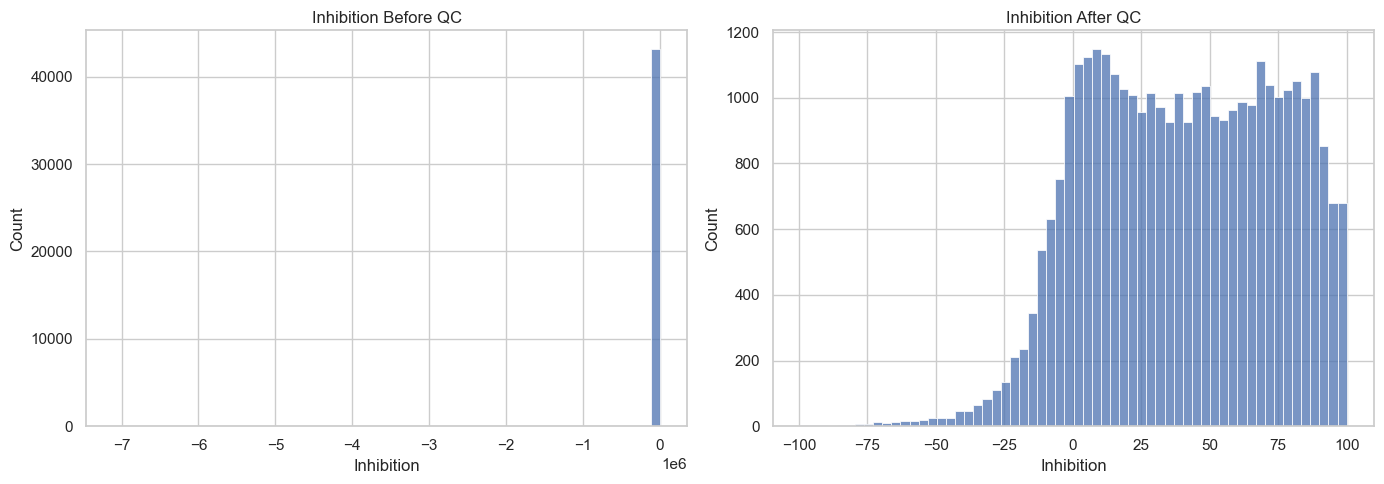

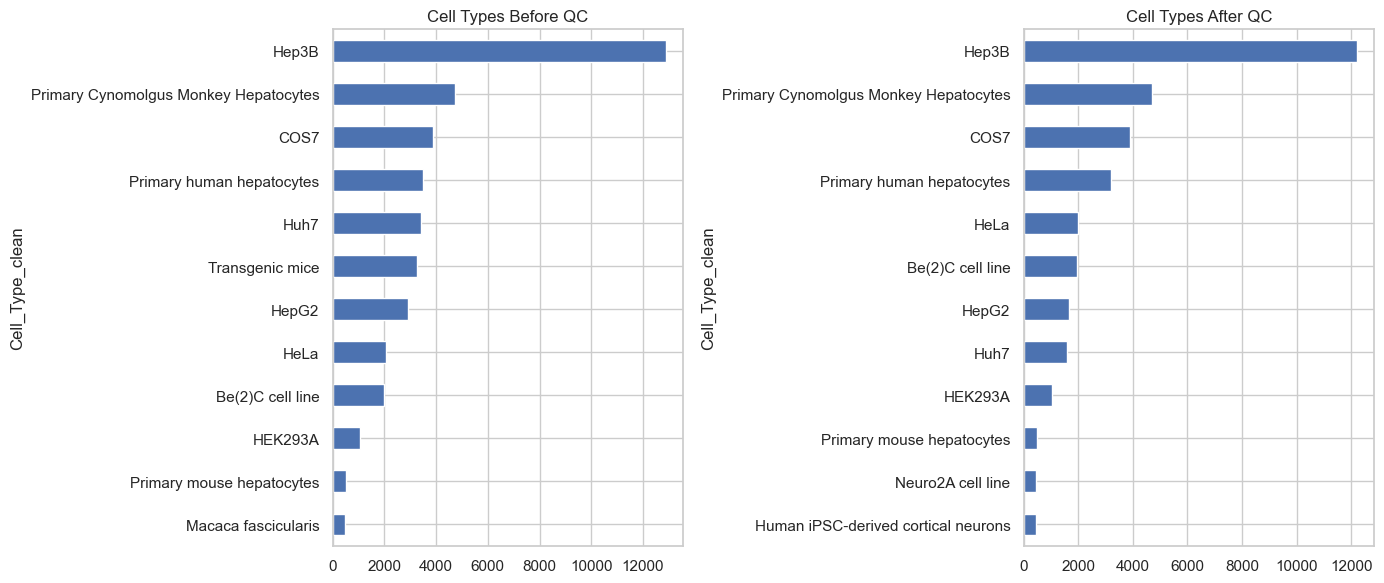

In [21]:
# Compare inhibition distributions before QC and after the no-mM cleaned subset.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Inhibition"], bins=60, ax=axes[0])
axes[0].set_title("Inhibition Before QC")
axes[0].set_xlabel("Inhibition")

sns.histplot(df_model["Inhibition"], bins=60, ax=axes[1])
axes[1].set_title("Inhibition After QC")
axes[1].set_xlabel("Inhibition")

plt.tight_layout()
plt.show()

# Compare the top cell types before QC and after the no-mM cleaned subset.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df["Cell_Type_clean"].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Cell Types Before QC")

df_model["Cell_Type_clean"].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Cell Types After QC")

plt.tight_layout()
plt.show()


## 13. Save QC Outputs

In [22]:
# Create output folders for processed data and QC artifacts.
processed_dir.mkdir(parents=True, exist_ok=True)

# Save the filtered modeling datasets, removed rows, and QC summary tables.
df_model.to_csv(processed_dir / "CMsiRNA_qc_modeling_subset_cleaned.tsv", sep="\t", index=False)
df_removed.to_csv(processed_dir / "CMsiRNA_qc_removed_rows.tsv", sep="\t", index=False)
qc_summary.to_csv(processed_dir / "CMsiRNA_qc_summary.csv", index=False)
missing_df.to_csv(processed_dir / "CMsiRNA_missingness.csv")

# Confirm where the outputs were written.
print("Saved outputs to:", processed_dir)


Saved outputs to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
